In [1]:
# BAO fitter using Y3 unblinded with Neff for Xi
# Basic
import numpy as np
import matplotlib.pyplot as plt
# desilike stuff
from cosmoprimo import fiducial
from desilike.theories.galaxy_clustering import BAOPowerSpectrumTemplate, DampedBAOWigglesTracerCorrelationFunctionMultipoles
from desilike.observables.galaxy_clustering import TracerCorrelationFunctionMultipolesObservable, BoxFootprint, ObservablesCovarianceMatrix
from desilike.likelihoods import ObservablesGaussianLikelihood
from desilike.profilers import MinuitProfiler
from desilike.samplers import EmceeSampler
from desilike.samples import plotting

## Settings

In [2]:
# Cosmology
cosmo_temp = fiducial.AbacusSummit(name='000', engine='class')
# Redshift
zeff = 0.8
# Smoothing scale
smoothing_radius = 10
# Cut scale
smin = 50.
smax = 150.
ds = 4.

## Parameters

In [3]:
# Parameters
apmode = 'qparqper'
rec_mode = 'recsym'
broadband = 'power3'
# outdir = args.outdir

# Derived parameters
ells = (0,) if apmode == 'qiso' else (0, 2)
slim = {ell: [smin, smax, ds] for ell in ells}

## Create fake data /covariance 

In [4]:
data = {'b1': 2.}
cov = None
# Template
template = BAOPowerSpectrumTemplate(z=zeff, fiducial=cosmo_temp)
# Theory
theory = DampedBAOWigglesTracerCorrelationFunctionMultipoles(template=template)
# Observable
observable = TracerCorrelationFunctionMultipolesObservable(data=data, covariance=cov, theory=theory, ells=ells, slim=slim)
# Likelihood
observable.init.update(data=observable.flatdata)  # fix the data vector
footprint = BoxFootprint(volume=5e9, nbar=1e-4)  # box with volume of 5 (Gpc/h)^3 and density of 1e-4 (h/Mpc)^3
covariance = ObservablesCovarianceMatrix(observables=[observable], footprints=[footprint])
likelihood = ObservablesGaussianLikelihood(observables=[observable], covariance=covariance(**data))
np.savetxt('/global/homes/h/hugoriv/BAO/data/cov.txt', 
           likelihood.covariance,
          )
np.savetxt('/global/homes/h/hugoriv/BAO/data/data.txt', 
           np.column_stack([observable.s[0], observable.data[0], observable.data[1]]), 
           header="s  xi0  xi2", 
          )

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260210-1.0.0/code/cosmoprimo/main/lib/python3.12/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260210-1.0.0/conda/lib/python3.12/site-packages/numpy/lib/_polynomial_impl.py:1355: FutureWarning: In the future extra properties will not be copied across when constructing one poly1d from another
  other = poly1d(other)


Count2CorrelationPoles(labels=[{'ells': 0}, {'ells': 2}], size=50)
Count2CorrelationPoles(labels=[{'ells': 0}, {'ells': 2}], size=50)


## Load data and covariance

In [5]:
# Data
poles = np.loadtxt("/global/homes/h/hugoriv/BAO/data/data.txt")
s_arr = poles[:, 0]
nbins = s_arr.shape[0]
data = np.concatenate([poles[:, 1], poles[:, 2]])
# Covariance
cov = np.loadtxt("/global/homes/h/hugoriv/BAO/data/cov.txt")

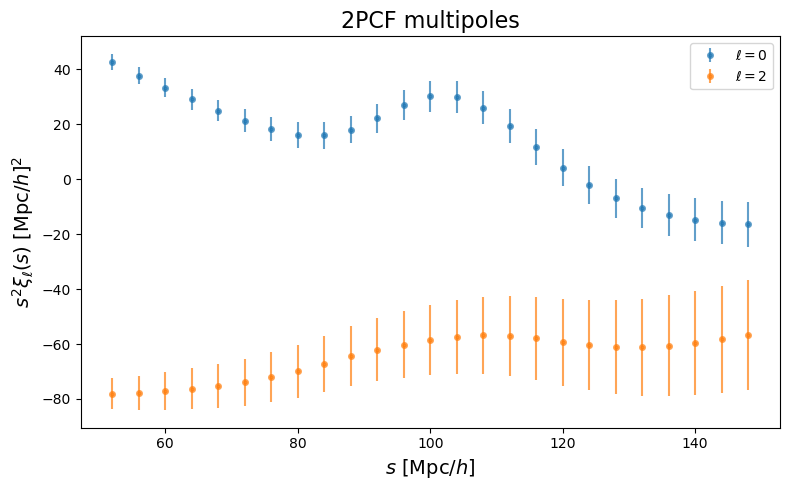

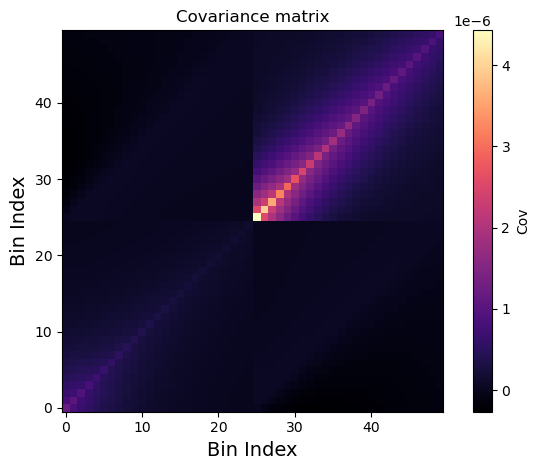

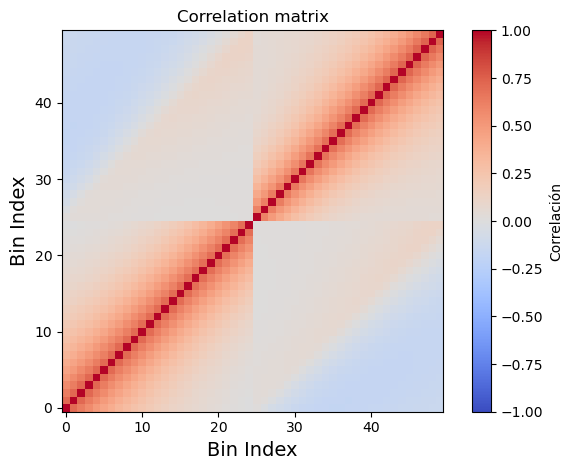

In [6]:
plt.figure(figsize=(8, 5))
plt.title('2PCF multipoles', fontsize=16)
plt.errorbar(s_arr, s_arr**2 * data[0:nbins], yerr=s_arr**2 * np.sqrt(np.diag(cov[:nbins, :nbins])),
            fmt='o', markersize=3.0, alpha=0.7, linestyle='', elinewidth=1.5, markeredgewidth=2.0, 
             label = r'$\ell = 0$',
             )
plt.errorbar(s_arr, s_arr**2 * data[nbins:2*nbins], yerr=s_arr**2 * np.sqrt(np.diag(cov[nbins:2*nbins, nbins:2*nbins])),
            fmt='o', markersize=3.0, alpha=0.7, linestyle='', elinewidth=1.5, markeredgewidth=2.0, 
             label = r'$\ell = 2$',
             )
plt.xlabel(r'$s$ [Mpc/$h$]', fontsize=14)
plt.ylabel(r'$s^2\xi_{\ell}(s)$ [Mpc/$h$]$^2$', fontsize=14)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

plt.imshow(cov, origin='lower', cmap='magma')
plt.colorbar(label='Cov')
plt.title(f'Covariance matrix')
plt.xlabel('Bin Index', fontsize=14)
plt.ylabel('Bin Index', fontsize=14)
plt.tight_layout()
plt.show()

std = np.sqrt(np.diag(cov))
corr_matrix = cov / np.outer(std, std)
plt.imshow(corr_matrix, origin='lower', cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlación')
plt.title(f'Correlation matrix')
plt.xlabel('Bin Index', fontsize=14)
plt.ylabel('Bin Index', fontsize=14)
plt.tight_layout()
plt.show()

## Build likelihood

In [7]:
# Template
template = BAOPowerSpectrumTemplate(
                                    z=zeff, 
                                    fiducial=cosmo_temp, 
                                    apmode=apmode, 
                                    with_now='wallish2018',
                                   )
# Theory
theory = DampedBAOWigglesTracerCorrelationFunctionMultipoles(
                                                             template=template, 
                                                             mode=rec_mode,
                                                             smoothing_radius=smoothing_radius,
                                                             broadband=broadband,
                                                            )
# Sigmas (no free-damping)
for param in theory.params.select(basename='sigma*'):
        param.update(fixed=False)
# Observable
observable = TracerCorrelationFunctionMultipolesObservable(
                                                           data=data, 
                                                           covariance=cov,
                                                           theory=theory, 
                                                           ells=ells,
                                                           slim=slim,
                                                           s=s_arr,
                                                          )
# Likelihood
likelihood = ObservablesGaussianLikelihood(observables=[observable])
# Fix some parameters
for param in likelihood.all_params.select(basename=['al4_*', 'bl4_*']):
    param.update(fixed=True)
# Priors
if rec_mode:
    sigmas = 2.0; sigmapar = 6.0; sigmaper = 3.0
else:
    sigmas = 2.0; sigmapar = 9.0; sigmaper = 4.5
likelihood.all_params['sigmas'].update(fixed=False, prior={'dist':'norm','loc': sigmas, 'scale': 2., 'limits': [0., 20]})
likelihood.all_params['sigmapar'].update(fixed=False, prior={'dist':'norm','loc': sigmapar, 'scale': 2., 'limits': [0., 20]})
likelihood.all_params['sigmaper'].update(fixed=False, prior={'dist':'norm','loc': sigmaper, 'scale': 1., 'limits': [0., 20]})

## Profiler

In [8]:
profiler = MinuitProfiler(likelihood, seed=42)
profiles = profiler.maximize(niterations=10)
likelihood(**profiles.bestfit.choice(input=True))

Array(-0.54289214, dtype=float64)

+-------------------------------------+--------+----------+---------+
| chi2 / (50 - 13) = 1.09 / 37 = 0.03 | varied | bestfit  |  error  |
+-------------------------------------+--------+----------+---------+
|                qpar                 |  True  |  0.998   |  0.034  |
|                qper                 |  True  |  0.999   |  0.021  |
|                 b1                  |  True  |   1.82   |  0.24   |
|                dbeta                |  True  |   0.87   |  0.47   |
|               sigmas                |  True  |   2.0    |   2.0   |
|              sigmapar               |  True  |   6.6    |   1.9   |
|              sigmaper               |  True  |   3.2    |   1.0   |
|               al0_-2                |  True  |  1.4e-4  | 2.0e-4  |
|               al0_-1                |  True  | -0.0004  | 0.0013  |
|                al0_0                |  True  |  0.0001  | 0.0021  |
|               al2_-2                |  True  | -0.00023 | 0.00083 |
|               al2_

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260210-1.0.0/code/desilike/lsstypes/lib/python3.12/site-packages/desilike/observables/galaxy_clustering/correlation_function.py:344: UserWarning: plot_wiggles is deprecated, use plot_bao instead
  warnings.warn('plot_wiggles is deprecated, use plot_bao instead')


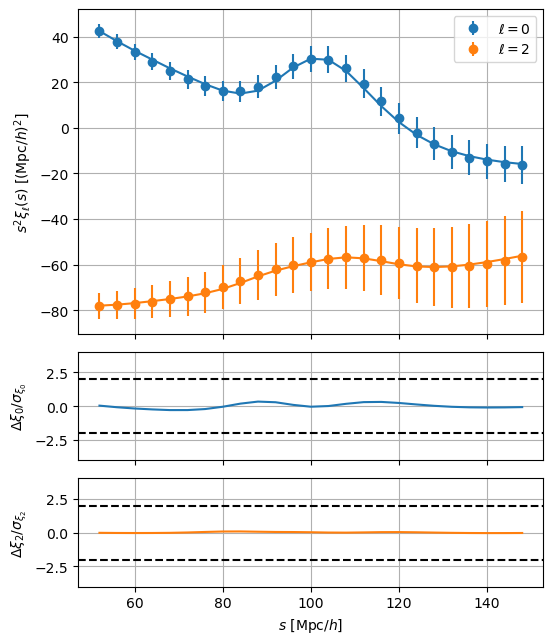

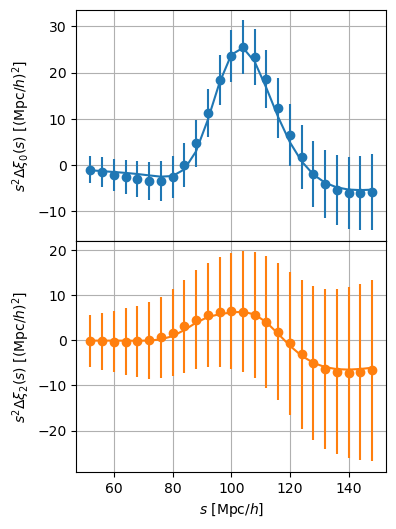

In [9]:
print(profiles.to_stats(tablefmt='pretty'))
observable.plot()
observable.plot_wiggles();
plt.show()

## Sampler

In [10]:
chains = 4
# save_fn = [samples_fn(outdir, f'{output_fn}_chain{i}.npy') for i in range(chains)]
sampler = EmceeSampler(likelihood, chains=chains, nwalkers=40, seed=42)#, save_fn=save_fn)
sampler.run(min_iterations=200, max_iterations=1000, check={'max_eigen_gr': 0.03})
chain = sampler.chains[0].remove_burnin(0.5)[::10]

+----------+---------+---------+---------+--------+-----------------+-----------------+
|          | argmax  |  mean   | median  |  std   | quantile:1sigma | interval:1sigma |
+----------+---------+---------+---------+--------+-----------------+-----------------+
|   qpar   |  0.974  |  0.997  |  0.996  | 0.035  |  -0.035/+0.033  |  -0.041/+0.025  |
|   qper   |  1.007  |  1.000  |  0.998  | 0.023  |  -0.022/+0.023  |  -0.023/+0.021  |
|    b1    |  1.76   |  1.77   |  1.78   |  0.21  |   -0.22/+0.21   |   -0.19/+0.23   |
|  dbeta   |  1.26   |  1.02   |  1.02   |  0.17  |   -0.19/+0.20   |   -0.11/+0.27   |
|  sigmas  |   1.7   |   2.7   |   2.5   |  1.6   |    -1.7/+1.7    |    -1.9/+1.4    |
| sigmapar |   7.7   |   6.8   |   6.9   |  1.8   |    -1.8/+1.7    |    -1.6/+1.9    |
| sigmaper |   3.2   |   3.4   |   3.4   |  1.0   |   -0.98/+1.02   |   -0.97/+1.04   |
|  al0_-2  |  0.e-6  | 1.3e-4  | 1.4e-4  | 2.1e-4 | -2.2e-4/+2.2e-4 | -2.0e-4/+2.3e-4 |
|  al0_-1  | 0.0005  | -0.0004 |

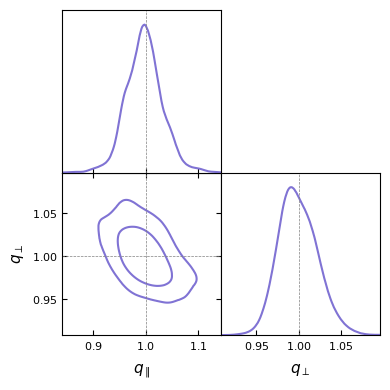

In [11]:
print(chain.to_stats(tablefmt='pretty'))
plotting.plot_triangle(chain,
                       ['qpar', 'qper'],
                       markers={'qpar': 1.0, 'qper': 1.0},  
                       contour_colors='#8073D4', 
                       contour_lws=1.5,
                       line_args={'lw': 1.5, 'color': '#8073D4', 'ls': '-'})